## 🔥 Diffusion 모델 라이브러리 (Diffuser)

Diffusion 모델을 활용한 이미지 생성 및 학습을 쉽게 할 수 있도록 라이브러리를 제공함. 

라이브러리는 다음과 같은 주요 구성 요소를 제공한다:

1️⃣ **DiffusionPipeline**  
   - 사전 학습된 Diffusion 모델을 사용하여 빠르게 샘플을 생성할 수 있는 **고수준 엔드 투 엔드 클래스**  
   - 간단한 인터페이스로 추론(inference)을 수행 가능
   - 여러 task를 수행할 수 있다

2️⃣ **모델 아키텍처 및 모듈**  
   - 다양한 **사전 학습된 모델 아키텍처** 및 모듈 제공  
   - Diffusion 시스템을 구축할 때 재사용할 수 있는 **유연한 구성 요소**  

3️⃣ **다양한 스케줄러(Schedulers)**  
   - 학습 중 **노이즈를 추가하는 방식**과 **추론 시 디노이징하는 방식**을 제어하는 다양한 알고리즘 지원  
   - 실험 및 연구 목적에 맞춰 **다양한 스케줄링 기법 적용 가능**  

## Quick Start
- DiffusionPipeline을 사용하여 단 2~3줄로 inference하기

In [2]:
# !pip install --upgrade diffusers accelerate transformers

In [1]:
from diffusers import DiffusionPipeline
pipeline = DiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", use_safetensors=True)

/home/qkboo/.pyenv/versions/3.12.1/envs/Goodyoung_P312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  9.53it/s]


100%|██████████| 50/50 [00:55<00:00,  1.12s/it]


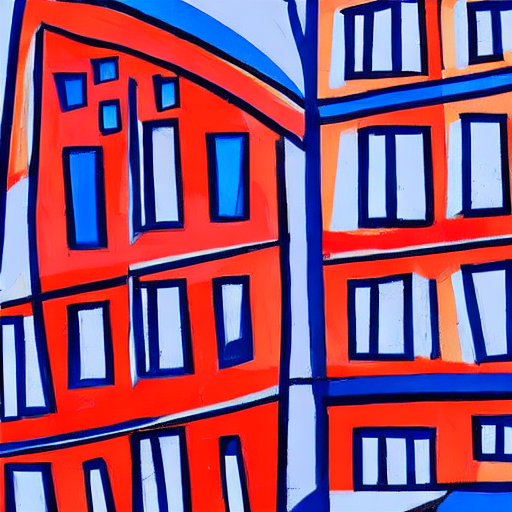

In [29]:
pipeline.to("cuda")
image = pipeline("An image of a red and blue building in Picasso style").images
image[0]
# image[0].save("sampel.png")

## Scheduler를 조작하기
- scheduler를 조작하여 최적화를 할 수 있다.
-  아래는 기존 PNDMScheduler -> EulerDiscreteScheduler로 변경하는 예시이다.
-  scheduler는 **trainable weight가 없고 parameter free이다.**

더 자세한 scheduler를 찾고 싶다면 [Schedulers 공식 사이트](https://huggingface.co/docs/diffusers/en/api/schedulers/overview)에서 찾으면 된다.

In [30]:
from diffusers import EulerDiscreteScheduler
print('기존: ',pipeline.scheduler.config._class_name)
pipeline.scheduler = EulerDiscreteScheduler.from_config(pipeline.scheduler.config) # 기존 설정을 기반으로 새로운 인스턴스 생성 (from_pretrain)
print('변경: ', pipeline.scheduler.config._class_name)

기존:  PNDMScheduler
변경:  EulerDiscreteScheduler


100%|██████████| 50/50 [00:56<00:00,  1.13s/it]


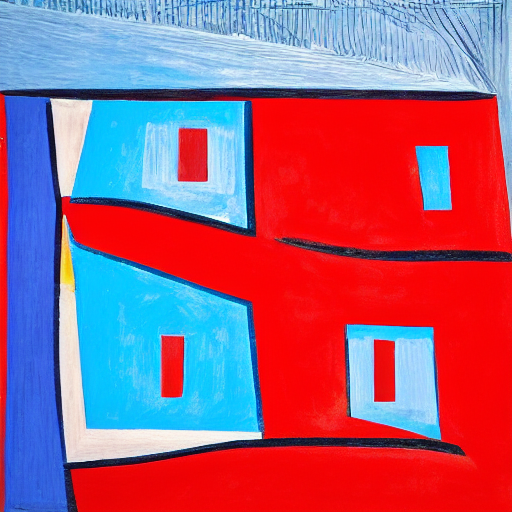

In [31]:
# scheduler 변경 시 바뀐 이미지 결과
image = pipeline("An image of a red and blue building in Picasso style").images
image[0]

In [1]:
from diffusers import UNet2DModel

repo_id = "google/ddpm-cat-256"
model = UNet2DModel.from_pretrained(repo_id, use_safetensors=True)

import torch

torch.manual_seed(0)

noisy_sample = torch.randn(1, model.config.in_channels, model.config.sample_size, model.config.sample_size)
noisy_sample.shape

with torch.no_grad():
    noisy_residual = model(sample=noisy_sample, timestep=2).sample

/home/qkboo/.pyenv/versions/3.12.1/envs/Goodyoung_P312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from diffusers import DDPMScheduler

scheduler = DDPMScheduler.from_pretrained(repo_id)

  5%|▍         | 49/1000 [00:02<00:40, 23.34it/s]

'Image at step 50'

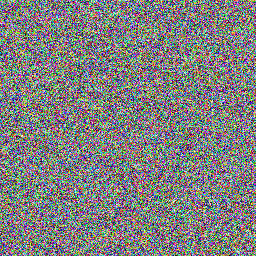

 10%|▉         | 97/1000 [00:04<00:34, 26.07it/s]

'Image at step 100'

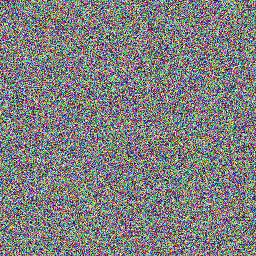

 15%|█▍        | 148/1000 [00:06<00:36, 23.55it/s]

'Image at step 150'

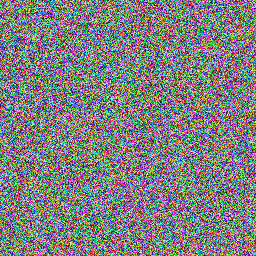

 20%|█▉        | 199/1000 [00:08<00:32, 24.42it/s]

'Image at step 200'

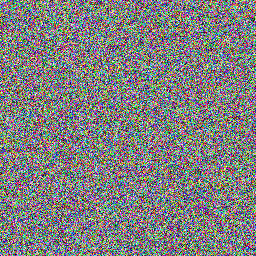

 25%|██▍       | 249/1000 [00:12<02:02,  6.13it/s]

'Image at step 250'

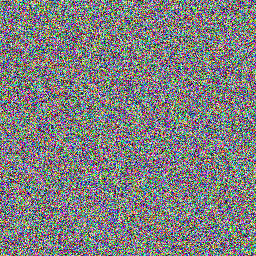

 30%|██▉       | 297/1000 [00:14<00:28, 24.96it/s]

'Image at step 300'

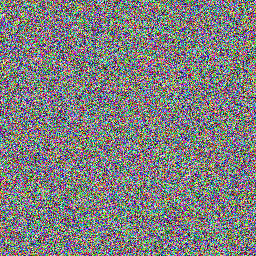

 35%|███▍      | 348/1000 [00:16<00:24, 26.50it/s]

'Image at step 350'

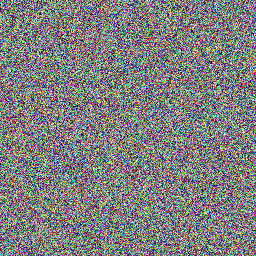

 40%|███▉      | 399/1000 [00:18<00:22, 27.18it/s]

'Image at step 400'

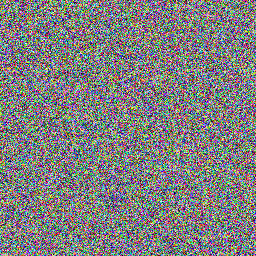

 45%|████▍     | 447/1000 [00:20<00:21, 25.50it/s]

'Image at step 450'

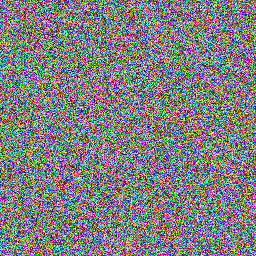

 50%|████▉     | 499/1000 [00:22<00:19, 25.81it/s]

'Image at step 500'

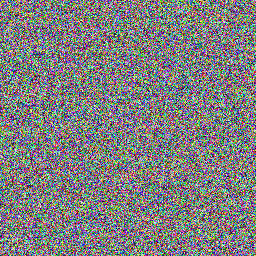

 55%|█████▍    | 547/1000 [00:24<00:17, 26.46it/s]

'Image at step 550'

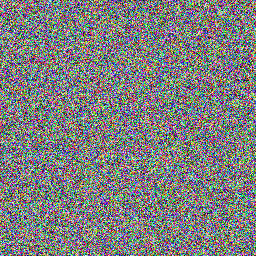

 60%|█████▉    | 598/1000 [00:26<00:15, 26.48it/s]

'Image at step 600'

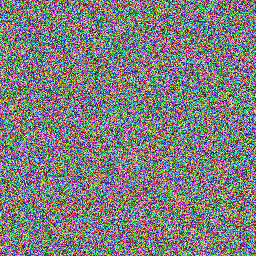

 65%|██████▍   | 649/1000 [00:28<00:13, 26.64it/s]

'Image at step 650'

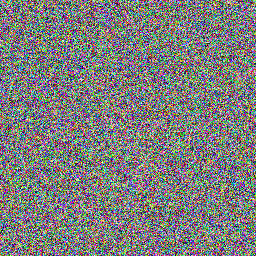

 70%|██████▉   | 697/1000 [00:29<00:11, 26.95it/s]

'Image at step 700'

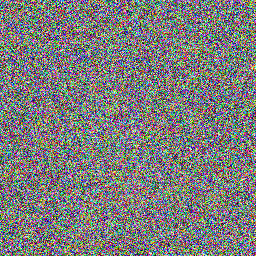

 75%|███████▍  | 749/1000 [00:31<00:10, 24.77it/s]

'Image at step 750'

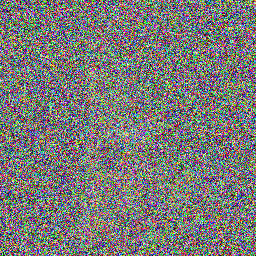

 80%|███████▉  | 797/1000 [00:33<00:07, 25.51it/s]

'Image at step 800'

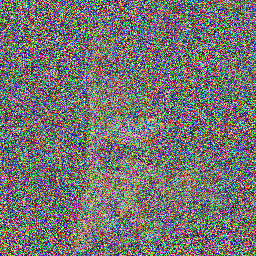

 85%|████████▍ | 848/1000 [00:35<00:06, 25.22it/s]

'Image at step 850'

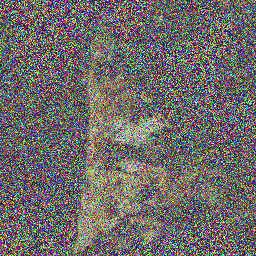

 90%|████████▉ | 899/1000 [00:38<00:04, 24.28it/s]

'Image at step 900'

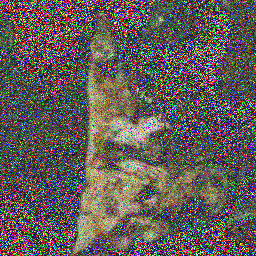

 95%|█████████▍| 947/1000 [00:40<00:02, 22.80it/s]

'Image at step 950'

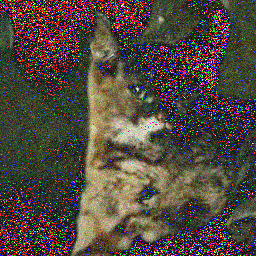

100%|█████████▉| 998/1000 [00:42<00:00, 23.11it/s]

'Image at step 1000'

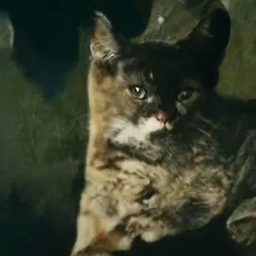

100%|██████████| 1000/1000 [00:42<00:00, 23.63it/s]


In [3]:
less_noisy_sample = scheduler.step(model_output=noisy_residual, timestep=2, sample=noisy_sample).prev_sample
less_noisy_sample.shape
import PIL.Image
import numpy as np


def display_sample(sample, i):
    image_processed = sample.cpu().permute(0, 2, 3, 1)
    image_processed = (image_processed + 1.0) * 127.5
    image_processed = image_processed.numpy().astype(np.uint8)

    image_pil = PIL.Image.fromarray(image_processed[0])
    display(f"Image at step {i}")
    display(image_pil)

model.to("cuda")
noisy_sample = noisy_sample.to("cuda")

import tqdm

sample = noisy_sample

for i, t in enumerate(tqdm.tqdm(scheduler.timesteps)):
    # 1. predict noise residual
    with torch.no_grad():
        residual = model(sample, t).sample

    # 2. compute less noisy image and set x_t -> x_t-1
    sample = scheduler.step(residual, t, sample).prev_sample

    # 3. optionally look at image
    if (i + 1) % 50 == 0:
        display_sample(sample, i + 1)